In [1]:
from sklearn.datasets import load_iris;

iris = load_iris();
X = iris['data'];
Y = iris['target'];

n_samples, n_features = X.shape;

print("Number of samples", n_samples);
print("Number of features", n_features);

Number of samples 150
Number of features 4


In [2]:
import numpy as np

class LDA:

    def __init__(self, n_components):
        self.n_components = n_components
        self.linear_discriminants = None

    def fit(self, X, y):
        n_features = X.shape[1]
        class_labels = np.unique(y)

        # Within class scatter matrix:
        # SW = sum((X_c - mean_X_c)^2 )

        # Between class scatter:
        # SB = sum( n_c * (mean_X_c - mean_overall)^2 )

        mean_overall = np.mean(X, axis=0)
        SW = np.zeros((n_features, n_features))
        SB = np.zeros((n_features, n_features))
        for c in class_labels:
            X_c = X[y == c]
            mean_c = np.mean(X_c, axis=0)
            # (4, n_c) * (n_c, 4) = (4,4) -> transpose
            SW += (X_c - mean_c).T.dot((X_c - mean_c))

            # (4, 1) * (1, 4) = (4,4) -> reshape
            n_c = X_c.shape[0]
            mean_diff = (mean_c - mean_overall).reshape(n_features, 1)
            SB += n_c * (mean_diff).dot(mean_diff.T)

        # Determine SW^-1 * SB
        print(SW)
        A = np.linalg.inv(SW).dot(SB)
        # Get eigenvalues and eigenvectors of SW^-1 * SB
        eigenvalues, eigenvectors = np.linalg.eig(A)
        # -> eigenvector v = [:,i] column vector, transpose for easier calculations
        # sort eigenvalues high to low
        eigenvectors = eigenvectors.T
        idxs = np.argsort(abs(eigenvalues))[::-1]
        eigenvalues = eigenvalues[idxs]
        eigenvectors = eigenvectors[idxs]
        # store first n eigenvectors
        self.linear_discriminants = eigenvectors[0:self.n_components]

    def transform(self, X):
        # project data
        return np.dot(X, self.linear_discriminants.T)

In [3]:
lda = LDA(n_features);
lda.fit(X, Y);

print(lda.linear_discriminants);

[[38.9562 13.63   24.6246  5.645 ]
 [13.63   16.962   8.1208  4.8084]
 [24.6246  8.1208 27.2226  6.2718]
 [ 5.645   4.8084  6.2718  6.1566]]
[[-0.20874182 -0.38620369  0.55401172  0.7073504 ]
 [-0.00653196 -0.58661055  0.25256154 -0.76945309]
 [ 0.15169622  0.28172319  0.35490222 -0.87844448]
 [ 0.87924206 -0.32816889 -0.31374947 -0.1442215 ]]


In [4]:
import numpy as np;

def standardize_data(X):
    return (X - np.mean(X, axis=0)) / np.std(X, axis = 0);


In [5]:
centered_X = standardize_data(X);

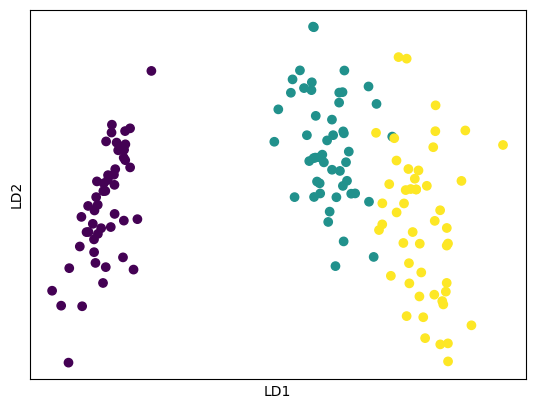

In [6]:
X_proj = lda.transform(X);

import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(X_proj[:, 0], X_proj[:, 1], c = Y)
plt.xlabel('LD1'); plt.xticks([])
plt.ylabel('LD2'); plt.yticks([])
plt.show()